In [1]:
import lfi
import torch
import numpy as np

## D: 40

### budget: 10_000

In [12]:
np.random.seed(21355)
torch.manual_seed(21)

In [13]:
# parameters
prior_dim= 40
prior_low = -10
prior_high = 10
simulator_dim_y = 40
observation_nof_obs = 1
simulator_sigma_noise=0.1

In [14]:
## Model parameters
budget =10_000
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [15]:
prior = lfi.priors.UniformPrior(low = prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.BimodalGaussian(dim=prior_dim, dim_y = simulator_dim_y, sigma_noise = simulator_sigma_noise)
obs = lfi.observations.Zeros(dim_y=simulator_dim_y, nof_observations = observation_nof_obs)
observation = obs.sample()

In [16]:
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior=prior,
    simulator=simulator,
    observation = observation,
)

In [17]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size
    }
)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 246 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [18]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [19]:
ground_truth = lfi.ground_truth.GaussianMixture(dim=prior_dim, mu=[-3, 3], sigma=[0.1, 0.1], weights = [0.5, 0.5])
samples_gt = ground_truth.return_samples(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

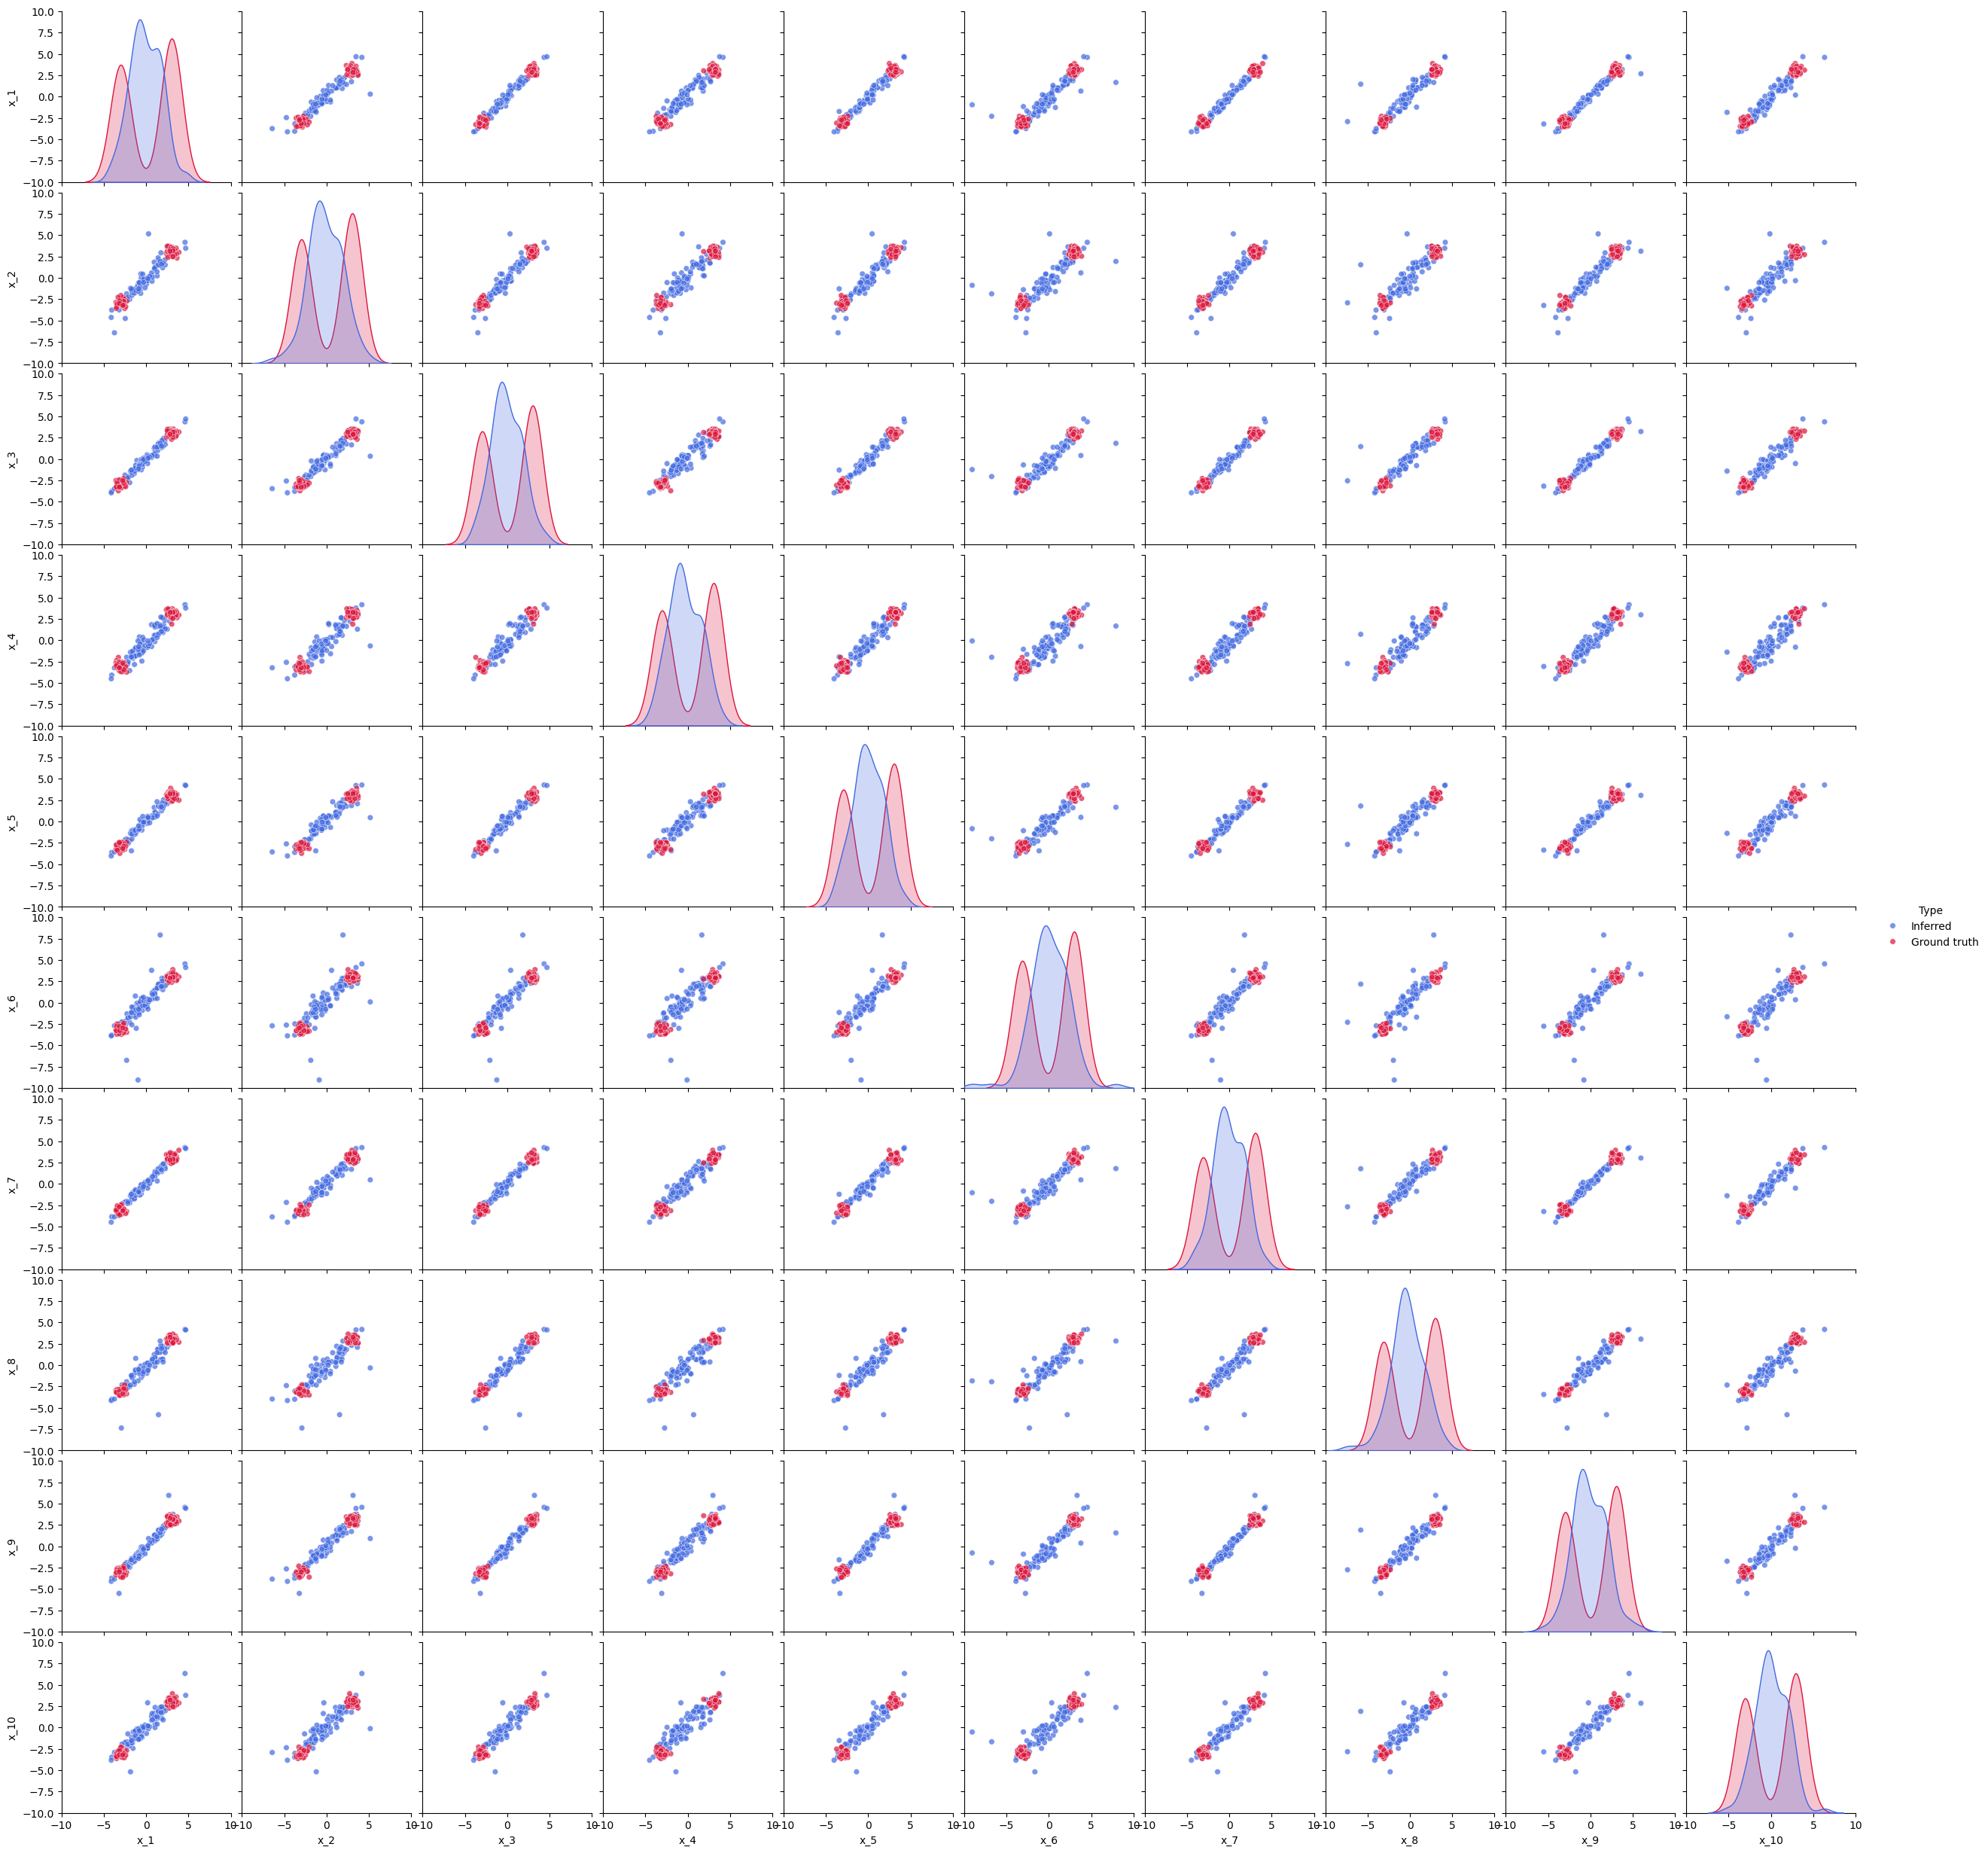

In [20]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [21]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"C2st is: {c2st}")

C2st is: 0.925


### budget: 50_000

In [11]:
np.random.seed(21355)
torch.manual_seed(21)

In [12]:
# parameters
prior_dim= 40
prior_low = -10
prior_high = 10
simulator_dim_y = 40
observation_nof_obs = 1
simulator_sigma_noise=0.1

In [13]:
## Model parameters
budget =50_000
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [14]:
prior = lfi.priors.UniformPrior(low = prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.BimodalGaussian(dim=prior_dim, dim_y = simulator_dim_y, sigma_noise = simulator_sigma_noise)
obs = lfi.observations.Zeros(dim_y=simulator_dim_y, nof_observations = observation_nof_obs)
observation = obs.sample()

In [15]:
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior=prior,
    simulator=simulator,
    observation = observation,
)

In [16]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size
    }
)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 178 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [17]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [18]:
ground_truth = lfi.ground_truth.GaussianMixture(dim=prior_dim, mu=[-3, 3], sigma=[0.1, 0.1], weights = [0.5, 0.5])
samples_gt = ground_truth.return_samples(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

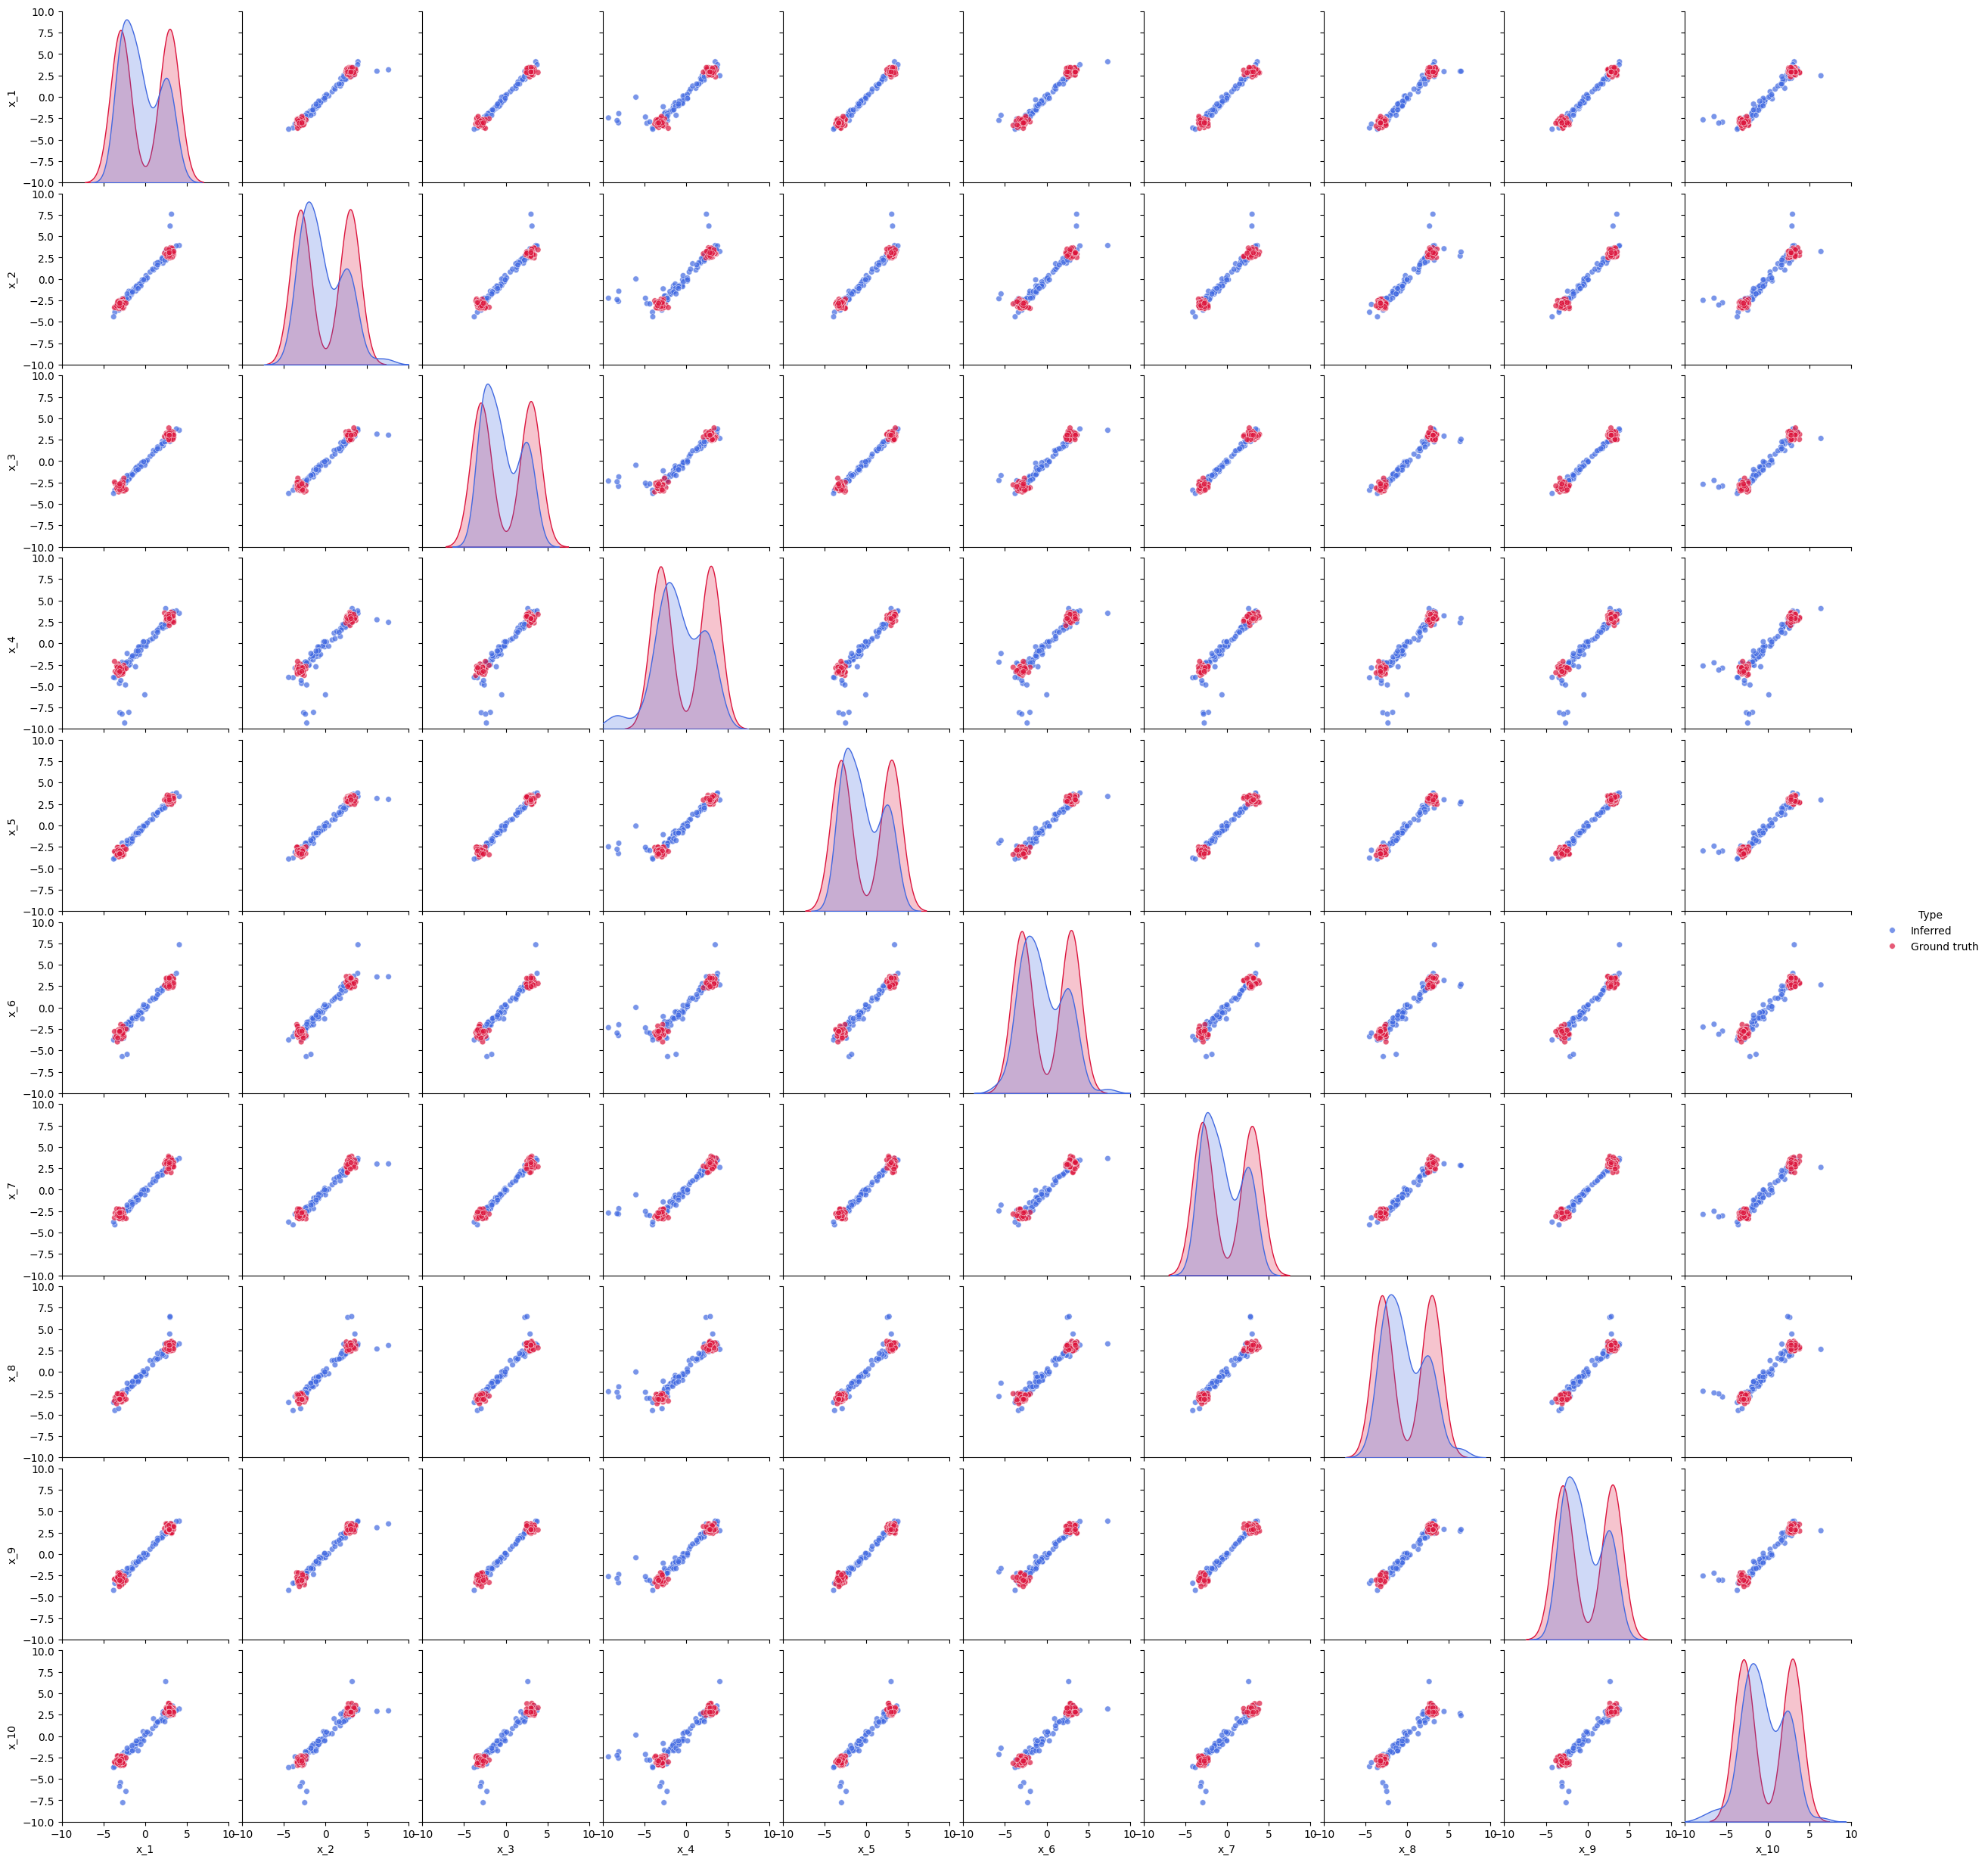

In [19]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [21]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
c2st

0.8150000000000001

### budget: 100_000

In [2]:
np.random.seed(21355)
torch.manual_seed(21)

In [3]:
# parameters
prior_dim= 40
prior_low = -10
prior_high = 10
simulator_dim_y = 40
observation_nof_obs = 1
simulator_sigma_noise=0.1

In [4]:
budget =100_000
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [5]:
prior = lfi.priors.UniformPrior(low = prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.BimodalGaussian(dim=prior_dim, dim_y = simulator_dim_y, sigma_noise = simulator_sigma_noise)
obs = lfi.observations.Zeros(dim_y=simulator_dim_y, nof_observations = observation_nof_obs)
observation = obs.sample()

In [6]:
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior=prior,
    simulator=simulator,
    observation = observation,
)

In [7]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size
    }
)

  0%|          | 0/100000 [00:00<?, ?it/s]

 Neural network successfully converged after 111 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [8]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2192.)
  outputs, _ = torch.triangular_solve(


In [9]:
ground_truth = lfi.ground_truth.GaussianMixture(dim=prior_dim, mu=[-3, 3], sigma=[0.1, 0.1], weights = [0.5, 0.5])
samples_gt = ground_truth.return_samples(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

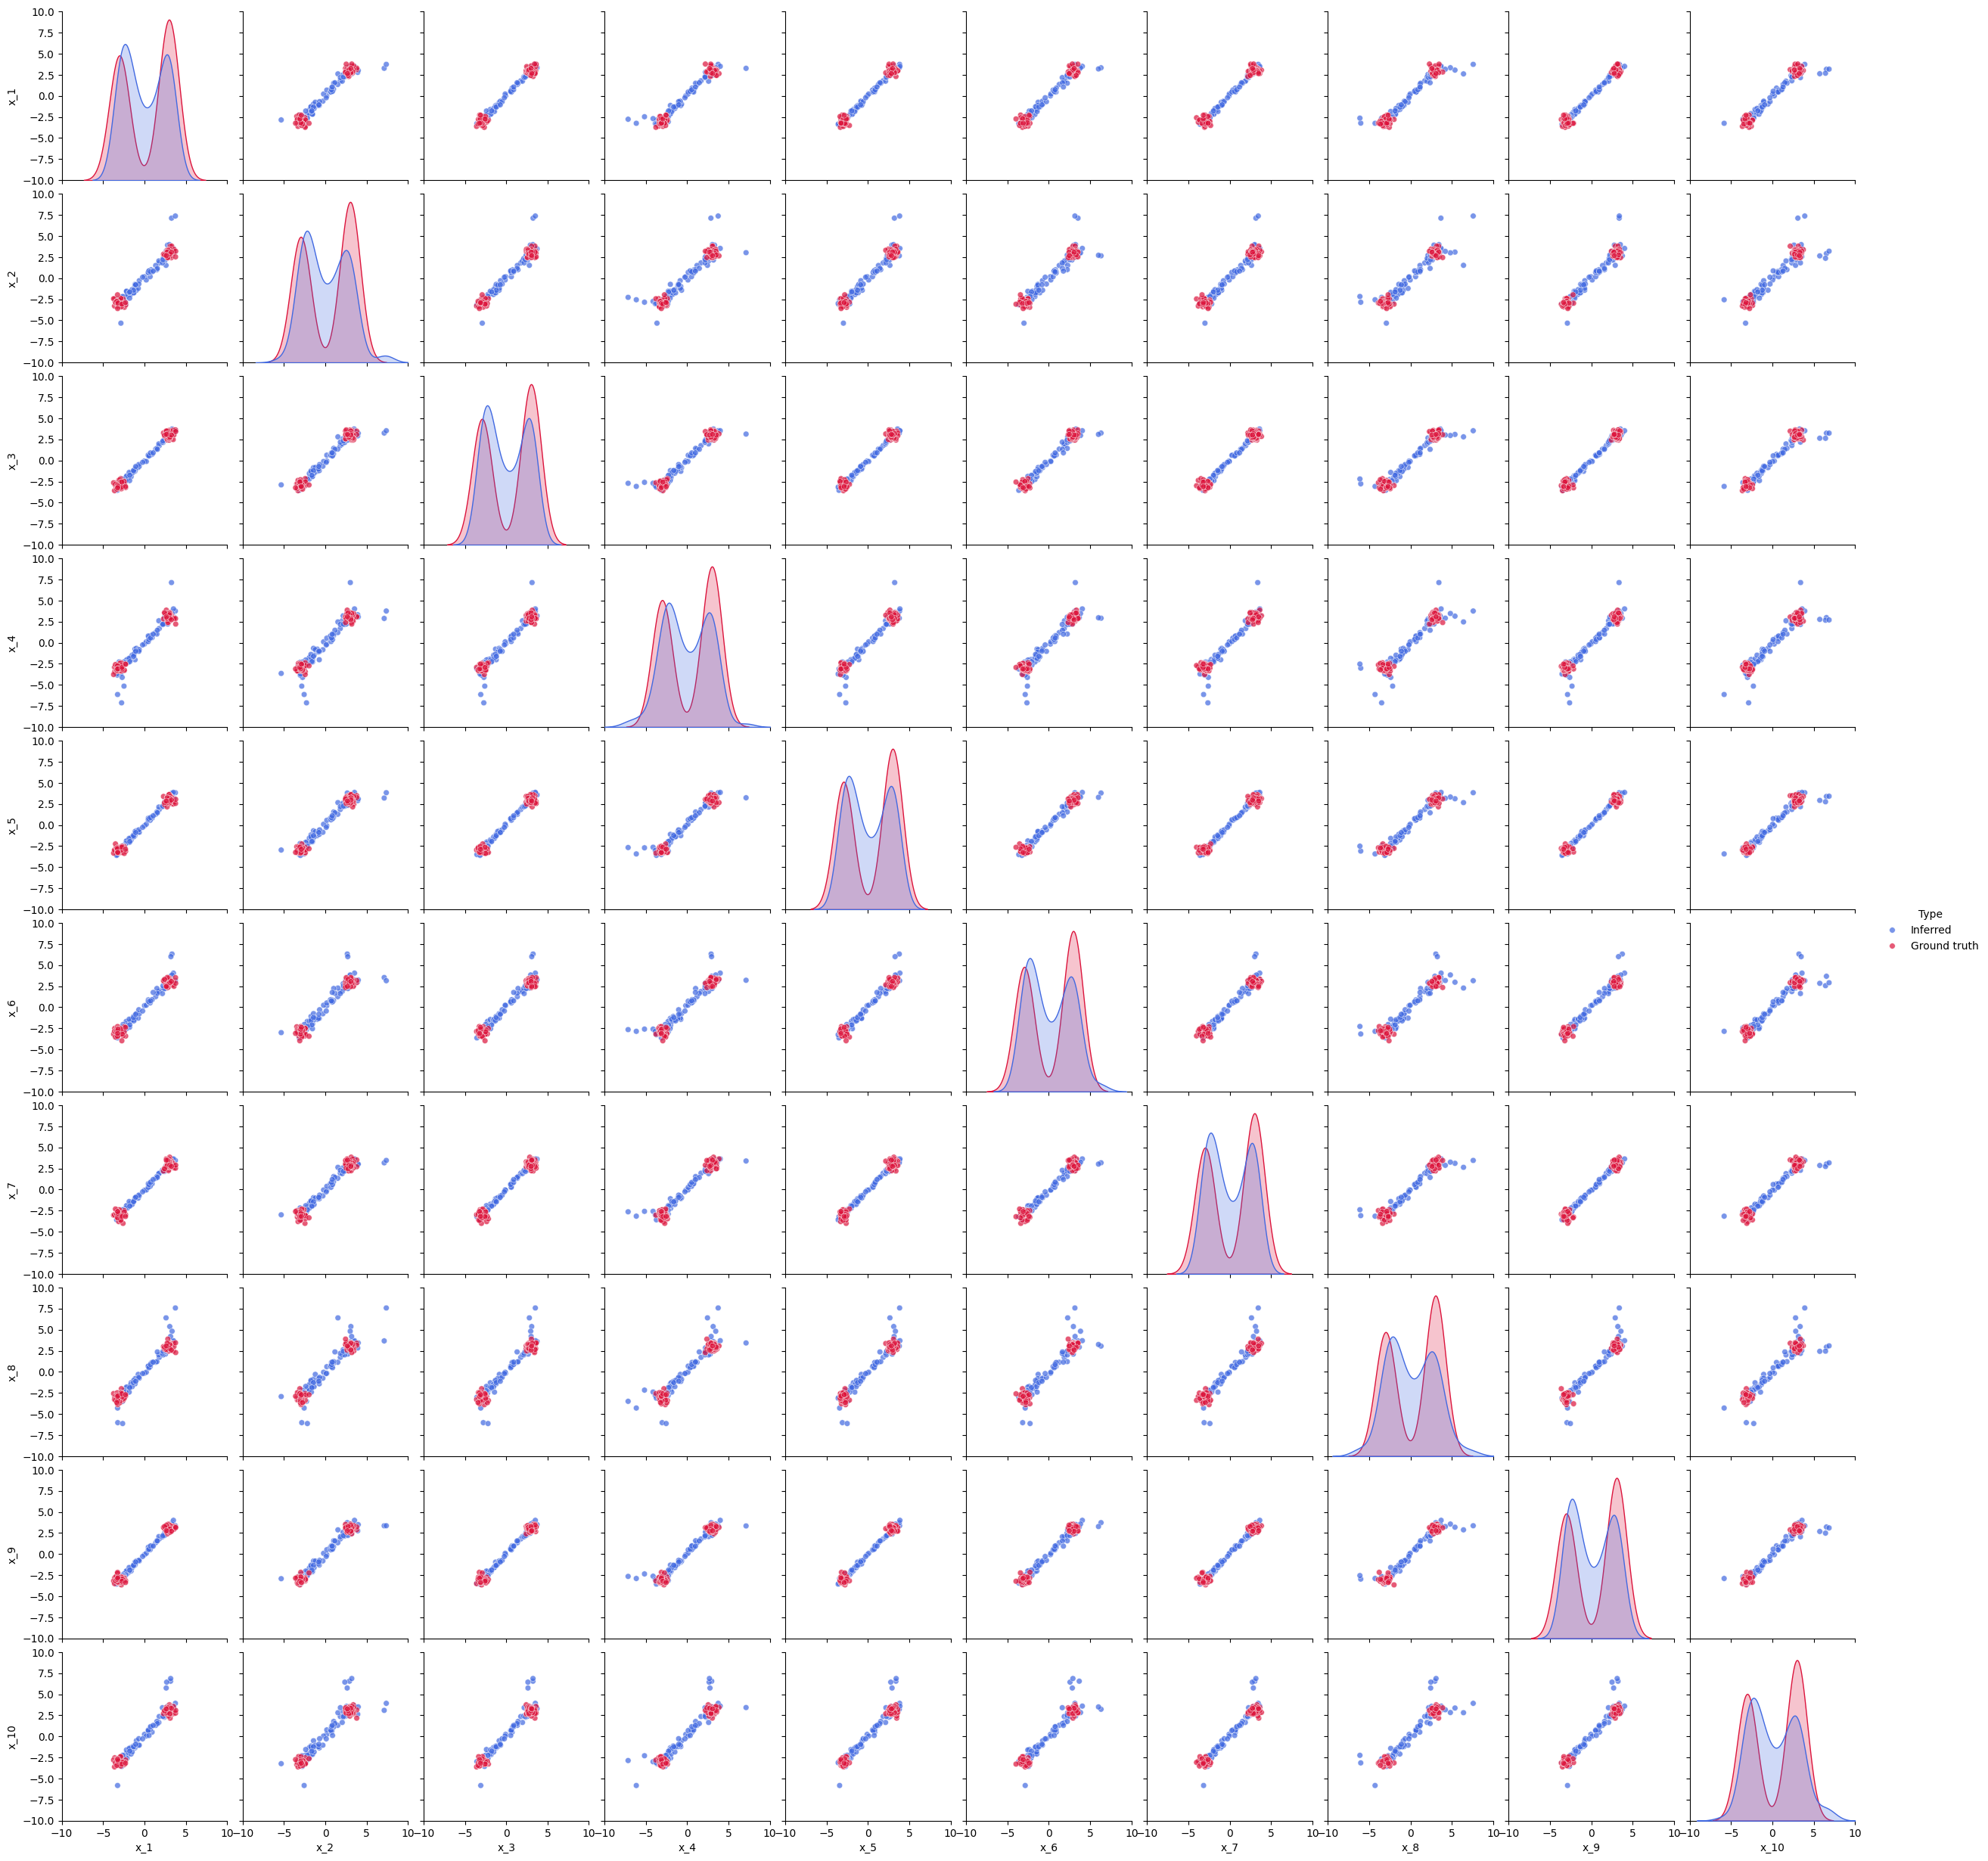

In [10]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [11]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"The c2st metric is: {c2st}")

The c2st metric is: 0.78
